In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Loan_Default_Project"

os.listdir(project_path)

['accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018Q4.csv.gz']

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)
from sklearn.linear_model import LogisticRegression

In [ ]:
selected_columns = [
    # Loan information
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",

    # Borrower information
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",

    # Loan details
    "issue_d",
    "purpose",
    "application_type",

    # Credit / risk indicators
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",

    # Financial indicators
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_util",
    "mort_acc",

    # Target
    "loan_status"
]

print("Number of selected columns:", len(selected_columns))

Number of selected columns: 31


In [ ]:
accepted_path = os.path.join(
    project_path,
    "accepted_2007_to_2018Q4.csv.gz"
)

chunk_size = 100_000

chunks = []

for chunk in pd.read_csv(
    accepted_path,
    compression="gzip",
    usecols=selected_columns,
    chunksize=chunk_size
):
    chunks.append(chunk)

accepted = pd.concat(chunks, ignore_index=True)

print("Dataset shape:", accepted.shape)

Dataset shape: (2260701, 31)


In [ ]:
accepted.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,revol_bal,revol_util,total_acc,application_type,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_util,mort_acc
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,2765.0,29.7,13.0,Individual,144904.0,9300.0,4.0,20701.0,37.2,1.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,21470.0,19.2,38.0,Individual,204396.0,111800.0,4.0,9733.0,27.1,4.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,7869.0,56.2,18.0,Joint App,189699.0,14000.0,6.0,31617.0,55.9,5.0
3,35000.0,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,...,7802.0,11.6,17.0,Individual,301500.0,67300.0,2.0,23192.0,12.1,1.0
4,10400.0,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,...,21929.0,64.5,35.0,Individual,331730.0,34000.0,10.0,27644.0,77.5,6.0


In [ ]:
accepted.shape

(2260701, 31)

In [ ]:
accepted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 31 columns):
 #   Column                Dtype  
---  ------                -----  
 0   loan_amnt             float64
 1   funded_amnt           float64
 2   term                  object 
 3   int_rate              float64
 4   installment           float64
 5   grade                 object 
 6   sub_grade             object 
 7   emp_length            object 
 8   home_ownership        object 
 9   annual_inc            float64
 10  verification_status   object 
 11  issue_d               object 
 12  loan_status           object 
 13  purpose               object 
 14  dti                   float64
 15  delinq_2yrs           float64
 16  fico_range_low        float64
 17  fico_range_high       float64
 18  inq_last_6mths        float64
 19  open_acc              float64
 20  pub_rec               float64
 21  revol_bal             float64
 22  revol_util            float64
 23  total_a

In [ ]:
accepted.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,...,pub_rec,revol_bal,revol_util,total_acc,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_util,mort_acc
count,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260638e+06,...,2.260639e+06,2.260668e+06,2.258866e+06,2.260639e+06,2.190392e+06,2.190392e+06,2.210638e+06,2.190322e+06,2.184597e+06,2.210638e+06
mean,1.504693e+04,1.504166e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,7.025884e+02,5.768354e-01,...,1.975278e-01,1.665846e+04,5.033770e+01,2.416255e+01,1.424922e+05,3.457394e+04,4.521656e+00,1.354780e+04,5.789995e+01,1.555382e+00
std,9.190245e+03,9.188413e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,3.301124e+01,8.859632e-01,...,5.705150e-01,2.294831e+04,2.471307e+01,1.198753e+01,1.606926e+05,3.672850e+04,3.164229e+00,1.647408e+04,2.858347e+01,1.904981e+00
min,5.000000e+02,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,6.790000e+02,0.000000e+00,...,0.000000e+00,5.950000e+03,3.150000e+01,1.500000e+01,2.909200e+04,1.470000e+04,2.000000e+00,3.080000e+03,3.540000e+01,0.000000e+00
50%,1.290000e+04,1.287500e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,6.940000e+02,0.000000e+00,...,0.000000e+00,1.132400e+04,5.030000e+01,2.200000e+01,7.924000e+04,2.540000e+04,4.000000e+00,7.335000e+03,6.020000e+01,1.000000e+00
75%,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,7.190000e+02,1.000000e+00,...,0.000000e+00,2.024600e+04,6.940000e+01,3.100000e+01,2.132040e+05,4.320000e+04,6.000000e+00,1.878300e+04,8.310000e+01,3.000000e+00
max,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,8.500000e+02,3.300000e+01,...,8.600000e+01,2.904836e+06,8.923000e+02,1.760000e+02,9.971659e+06,9.999999e+06,6.400000e+01,9.580840e+05,3.396000e+02,9.400000e+01


In [ ]:
accepted["loan_status"].value_counts(dropna=False)

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [ ]:
missing = pd.DataFrame({
    "Missing_Count": accepted.isnull().sum(),
    "Missing_Percentage": accepted.isnull().mean() * 100
}).sort_values(
    "Missing_Percentage",
    ascending=False
)

missing.head(20)

,Missing_Count,Missing_Percentage
emp_length,146940,6.499754
bc_util,76104,3.366389
avg_cur_bal,70379,3.113149
total_rev_hi_lim,70309,3.110053
tot_cur_bal,70309,3.110053
acc_open_past_24mths,50063,2.214490
mort_acc,50063,2.214490
revol_util,1835,0.081170
dti,1744,0.077144
inq_last_6mths,63,0.002787


In [ ]:
accepted.duplicated().sum()

np.int64(32)

In [ ]:
accepted.duplicated(subset=["loan_amnt", "issue_d", "annual_inc"]).sum()

np.int64(1278624)

In [ ]:
final_statuses = [
    "Fully Paid",
    "Charged Off",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off",
    "Default"
]

model_data = accepted[
    accepted["loan_status"].isin(final_statuses)
].copy()

print("Modeling dataset shape:", model_data.shape)

Modeling dataset shape: (1348099, 31)


In [ ]:
model_data["loan_status"].value_counts()

,count
loan_status,
Fully Paid,1076751
Charged Off,268559
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [ ]:
default_statuses = [
    "Charged Off",
    "Default",
    "Does not meet the credit policy. Status:Charged Off"
]

model_data["default"] = model_data["loan_status"].isin(
    default_statuses
).astype(int)

In [ ]:
model_data["default"].value_counts()

,count
default,
0,1078739
1,269360


In [ ]:
model_data["default"].value_counts(normalize=True) * 100

,proportion
default,
0,80.019272
1,19.980728


In [ ]:
overall_default_rate = model_data["default"].mean() * 100

print(f"Overall default rate: {overall_default_rate:.2f}%")

Overall default rate: 19.98%


In [ ]:
grade_default_rate = (
    model_data.groupby("grade")["default"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

grade_default_rate["default_rate_%"] = grade_default_rate["mean"] * 100

grade_default_rate

,count,mean,default_rate_%
grade,,,
G,9326,0.496676,49.667596
F,32306,0.451464,45.146412
E,94192,0.384311,38.431077
D,201657,0.303803,30.380299
C,382323,0.224431,22.443065
B,393102,0.133963,13.396269
A,235193,0.060435,6.043547


In [ ]:
model_data["income_bracket"] = pd.cut(
    model_data["annual_inc"],
    bins=[0, 30000, 50000, 75000, 100000, 150000, float("inf")],
    labels=[
        "<30K",
        "30K-50K",
        "50K-75K",
        "75K-100K",
        "100K-150K",
        "150K+"
    ]
)

In [ ]:
income_default_rate = (
    model_data.groupby("income_bracket", observed=False)["default"]
    .agg(["count", "mean"])
)

income_default_rate["default_rate_%"] = (
    income_default_rate["mean"] * 100
)

income_default_rate

,count,mean,default_rate_%
income_bracket,,,
<30K,99407,0.243755,24.375547
30K-50K,334459,0.225008,22.500815
50K-75K,412616,0.204973,20.497266
75K-100K,250780,0.182650,18.265013
100K-150K,179178,0.161878,16.187813
150K+,71294,0.146155,14.615536


In [ ]:
important_columns = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "issue_d",
    "purpose",
    "application_type",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_util",
    "mort_acc"
]

cleaning_check = pd.DataFrame({
    "dtype": model_data[important_columns].dtypes,
    "missing": model_data[important_columns].isnull().sum(),
    "missing_%": model_data[important_columns].isnull().mean() * 100
})

cleaning_check.sort_values("missing_%", ascending=False)

,dtype,missing,missing_%
emp_length,object,78550,5.826723
avg_cur_bal,float64,70298,5.214602
total_rev_hi_lim,float64,70276,5.212970
tot_cur_bal,float64,70276,5.212970
bc_util,float64,64663,4.796606
mort_acc,float64,50030,3.711152
acc_open_past_24mths,float64,50030,3.711152
revol_util,float64,897,0.066538
dti,float64,374,0.027743
inq_last_6mths,float64,30,0.002225


In [ ]:
categorical_columns = [
    "term",
    "grade",
    "sub_grade",
    "emp_length",
    "home_ownership",
    "verification_status",
    "purpose",
    "application_type"
]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(col)
    print(model_data[col].value_counts(dropna=False).head(20))


term
term
36 months    1023206
60 months     324893
Name: count, dtype: int64

grade
grade
B    393102
C    382323
A    235193
D    201657
E     94192
F     32306
G      9326
Name: count, dtype: int64

sub_grade
sub_grade
C1    85618
B4    83276
B5    82639
B3    81901
C2    79358
C3    75129
C4    74554
B2    74080
B1    71206
C5    67664
A5    64056
A4    52255
D1    51445
D2    44984
A1    43682
D3    39466
A3    38010
A2    37190
D4    35722
D5    30040
Name: count, dtype: int64

emp_length
emp_length
10+ years    442679
2 years      122100
< 1 year     108537
3 years      107868
1 year        88843
5 years       84326
4 years       80763
NaN           78550
6 years       62879
8 years       60811
7 years       59724
9 years       51019
Name: count, dtype: int64

home_ownership
home_ownership
MORTGAGE    666852
RENT        535699
OWN         145027
ANY            286
OTHER          182
NONE            53
Name: count, dtype: int64

verification_status
verification_status
Source Ver

In [ ]:
numerical_columns = [
    "loan_amnt",
    "funded_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_util",
    "mort_acc"
]

model_data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1348099.0,14408.998913,8716.137925,500.00,7975.00,12000.00,20000.00,40000.00
funded_amnt,1348099.0,14400.187004,8712.249793,500.00,7950.00,12000.00,20000.00,40000.00
int_rate,1348099.0,13.241562,4.765685,5.31,9.75,12.74,15.99,30.99
installment,1348099.0,437.777843,261.497190,4.93,248.28,375.04,580.22,1719.83
annual_inc,1348095.0,76237.743295,69922.741975,0.00,45750.00,65000.00,90000.00,10999200.00
dti,1347725.0,18.274253,11.155495,-1.00,11.79,17.61,24.05,999.00
delinq_2yrs,1348070.0,0.317633,0.877744,0.00,0.00,0.00,0.00,39.00
fico_range_low,1348099.0,696.162233,31.850787,610.00,670.00,690.00,710.00,845.00
fico_range_high,1348099.0,700.162371,31.851434,614.00,674.00,694.00,714.00,850.00
inq_last_6mths,1348069.0,0.662204,0.960071,0.00,0.00,0.00,1.00,33.00


In [ ]:
model_data["term_months"] = (
    model_data["term"]
    .str.extract(r"(\d+)")
    .astype(float)
)

model_data["term_months"].value_counts()

,count
term_months,
36.0,1023206
60.0,324893


In [ ]:
model_data["emp_length_years"] = (
    model_data["emp_length"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [ ]:
model_data["emp_length_years"] = (
    model_data["emp_length"]
    .replace({
        "< 1 year": "0",
        "10+ years": "10"
    })
    .str.extract(r"(\d+)")
    .astype(float)
)

In [ ]:
model_data["emp_length_years"].value_counts(dropna=False).sort_index()

,count
emp_length_years,
0.0,108537
1.0,88843
2.0,122100
3.0,107868
4.0,80763
5.0,84326
6.0,62879
7.0,59724
8.0,60811


In [ ]:
model_data["fico_score"] = (
    model_data["fico_range_low"] +
    model_data["fico_range_high"]
) / 2

In [ ]:
model_data["fico_score"].describe()

,fico_score
count,1.348099e+06
mean,6.981623e+02
std,3.185111e+01
min,6.120000e+02
25%,6.720000e+02
50%,6.920000e+02
75%,7.120000e+02
max,8.475000e+02


In [ ]:
model_data.loc[
    model_data["dti"] < 0,
    "dti"
] = np.nan

In [ ]:
model_data.loc[
    model_data["revol_util"] > 100,
    "revol_util"
] = np.nan

model_data.loc[
    model_data["bc_util"] > 100,
    "bc_util"
] = np.nan

In [ ]:
model_data[["dti", "revol_util", "bc_util"]].describe()

,dti,revol_util,bc_util
count,1.347723e+06,1.342488e+06,1.262175e+06
mean,1.827428e+01,5.163066e+01,5.921821e+01
std,1.115548e+01,2.436733e+01,2.796184e+01
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.179000e+01,3.340000e+01,3.780000e+01
50%,1.761000e+01,5.200000e+01,6.240000e+01
75%,2.405000e+01,7.050000e+01,8.390000e+01
max,9.990000e+02,1.000000e+02,1.000000e+02


In [ ]:
model_data["annual_inc"].quantile(
    [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 1]
)

,annual_inc
0.000,0.0
0.010,18000.0
0.050,28000.0
0.250,45750.0
0.500,65000.0
0.750,90000.0
0.950,155000.0
0.990,251000.0
0.995,325000.0
1.000,10999200.0


In [ ]:
model_data[
    [
        "annual_inc",
        "dti",
        "revol_util",
        "bc_util",
        "fico_score",
        "emp_length_years",
        "term_months"
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
annual_inc,1348095.0,76237.743295,69922.741975,0.0,45750.00,65000.00,90000.00,10999200.0
dti,1347723.0,18.274282,11.155478,0.0,11.79,17.61,24.05,999.0
revol_util,1342488.0,51.630657,24.367326,0.0,33.40,52.00,70.50,100.0
bc_util,1262175.0,59.218213,27.961837,0.0,37.80,62.40,83.90,100.0
fico_score,1348099.0,698.162302,31.851110,612.0,672.00,692.00,712.00,847.5
emp_length_years,1269549.0,5.962054,3.691822,0.0,2.00,6.00,10.00,10.0
term_months,1348099.0,41.784020,10.264584,36.0,36.00,36.00,36.00,60.0


In [ ]:
#Step 13 — FICO score vs default
#Create FICO bands:
model_data["fico_band"] = pd.cut(
    model_data["fico_score"],
    bins=[600, 650, 680, 700, 720, 750, 900],
    labels=[
        "600-649",
        "650-679",
        "680-699",
        "700-719",
        "720-749",
        "750+"
    ]
)

In [ ]:
fico_default = (
    model_data.groupby("fico_band", observed=False)["default"]
    .agg(["count", "mean"])
)

fico_default["default_rate_%"] = fico_default["mean"] * 100

fico_default

,count,mean,default_rate_%
fico_band,,,
600-649,231,0.320346,32.034632
650-679,460473,0.253003,25.300289
680-699,362009,0.214486,21.448638
700-719,246676,0.173000,17.300021
720-749,172053,0.133575,13.357512
750+,106657,0.088902,8.890181


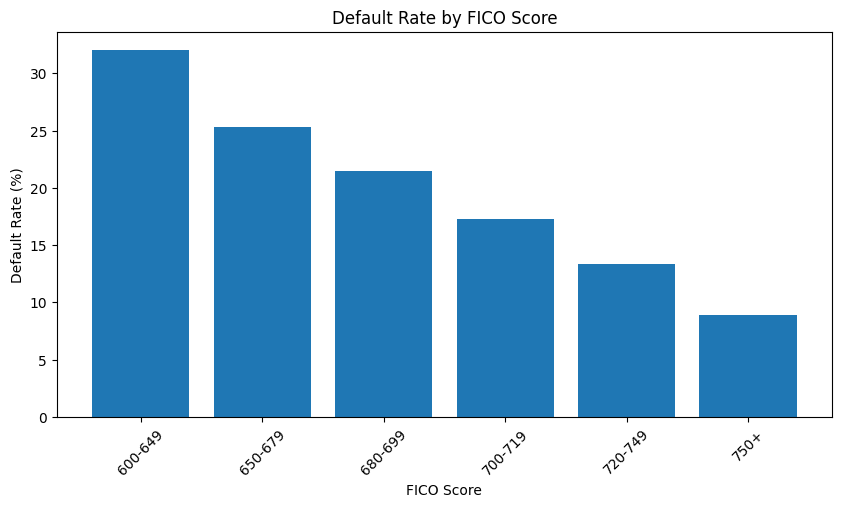

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    fico_default.index.astype(str),
    fico_default["default_rate_%"]
)

plt.xlabel("FICO Score")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by FICO Score")
plt.xticks(rotation=45)

plt.show()

In [ ]:
model_data["dti_clean"] = model_data["dti"].where(
    model_data["dti"] <= 100,
    np.nan
)

In [ ]:
model_data["dti_band"] = pd.cut(
    model_data["dti_clean"],
    bins=[-0.01, 10, 20, 30, 40, 50, 100],
    labels=[
        "<10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%",
        "50%+"
    ]
)

In [ ]:
dti_default = (
    model_data.groupby("dti_band", observed=False)["default"]
    .agg(["count", "mean"])
)

dti_default["default_rate_%"] = dti_default["mean"] * 100

dti_default

,count,mean,default_rate_%
dti_band,,,
<10%,247033,0.149235,14.923512
10-20%,563348,0.178710,17.871014
20-30%,409035,0.230565,23.056462
30-40%,121541,0.291021,29.102114
40-50%,3992,0.318637,31.863727
50%+,2241,0.290942,29.094154


In [ ]:
employment_default = (
    model_data.groupby(
        "emp_length_years",
        dropna=False
    )["default"]
    .agg(["count", "mean"])
)

employment_default["default_rate_%"] = (
    employment_default["mean"] * 100
)

employment_default

,count,mean,default_rate_%
emp_length_years,,,
0.0,108537,0.205423,20.542304
1.0,88843,0.205869,20.586878
2.0,122100,0.198239,19.823915
3.0,107868,0.199902,19.990173
4.0,80763,0.197590,19.759048
5.0,84326,0.196203,19.620283
6.0,62879,0.193785,19.378489
7.0,59724,0.195097,19.509745
8.0,60811,0.199553,19.955271


In [ ]:
purpose_default = (
    model_data.groupby("purpose")["default"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

purpose_default["default_rate_%"] = (
    purpose_default["mean"] * 100
)

purpose_default

,count,mean,default_rate_%
purpose,,,
small_business,15577,0.298645,29.864544
renewable_energy,936,0.237179,23.717949
moving,9526,0.233991,23.399118
house,7298,0.219101,21.910112
medical,15614,0.218458,21.845779
debt_consolidation,781442,0.211567,21.156657
other,78301,0.210827,21.082745
educational,423,0.208038,20.803783
vacation,9084,0.191986,19.198591


In [ ]:
model_data["interest_rate_band"] = pd.cut(
    model_data["int_rate"],
    bins=[0, 8, 12, 16, 20, 25, 35],
    labels=[
        "<8%",
        "8-12%",
        "12-16%",
        "16-20%",
        "20-25%",
        "25%+"
    ]
)

In [ ]:
interest_default = (
    model_data.groupby(
        "interest_rate_band",
        observed=False
    )["default"]
    .agg(["count", "mean"])
)

interest_default["default_rate_%"] = (
    interest_default["mean"] * 100
)

interest_default

,count,mean,default_rate_%
interest_rate_band,,,
<8%,208480,0.058255,5.825499
8-12%,382853,0.133563,13.356301
12-16%,421351,0.215849,21.584854
16-20%,228223,0.312869,31.286943
20-25%,80857,0.385087,38.508725
25%+,26335,0.478109,47.810898


In [ ]:
model_data["loan_amount_band"] = pd.cut(
    model_data["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 30000, 50000],
    labels=[
        "<5K",
        "5K-10K",
        "10K-15K",
        "15K-20K",
        "20K-30K",
        "30K+"
    ]
)

In [ ]:
loan_amount_default = (
    model_data.groupby(
        "loan_amount_band",
        observed=False
    )["default"]
    .agg(["count", "mean"])
)

loan_amount_default["default_rate_%"] = (
    loan_amount_default["mean"] * 100
)

loan_amount_default

,count,mean,default_rate_%
loan_amount_band,,,
<5K,182982,0.158179,15.817949
5K-10K,374487,0.172385,17.238516
10K-15K,284205,0.207804,20.780423
15K-20K,214373,0.226362,22.636246
20K-30K,210673,0.229503,22.950259
30K+,81379,0.244842,24.484204


In [ ]:
# ============================================================
# STEP 19: ADD GEOGRAPHY INFORMATION
# ============================================================

# Read ONLY the state column from the original dataset.
# We don't need to reload all 151 columns.
state_data = pd.read_csv(
    accepted_path,
    compression="gzip",
    usecols=["addr_state"]
)

# Check that we loaded the expected number of records.
print("State data shape:", state_data.shape)

State data shape: (2260701, 1)


In [ ]:
# Add the state information to model_data.
# The index is preserved from the original dataset,
# so we can align the state values with our records.

model_data["addr_state"] = state_data.loc[
    model_data.index, "addr_state"
].values

# Check the first few states
model_data["addr_state"].head()

,addr_state
0,PA
1,SD
2,IL
4,PA
5,GA


In [ ]:
# Remove the temporary dataframe to free memory.

del state_data

In [ ]:
# ============================================================
# STEP 20: DEFAULT RATE BY STATE
# ============================================================

# Group loans by state.
# For each state:
#   - count = number of loans
#   - mean = default rate because default is 0 or 1

state_default = (
    model_data.groupby("addr_state")["default"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

# Convert the default rate from decimal to percentage.

state_default["default_rate_%"] = (
    state_default["mean"] * 100
)

# Display the results.

state_default

,count,mean,default_rate_%
addr_state,,,
MS,6595,0.261107,26.110690
NE,3592,0.252227,25.222717
AR,10062,0.241105,24.110515
AL,16645,0.236347,23.634725
OK,12298,0.234672,23.467230
LA,15524,0.231770,23.177016
NY,110097,0.220506,22.050555
NV,20296,0.219698,21.969846
FL,95843,0.215018,21.501831


In [ ]:
# ============================================================
# STEP 21: FILTER STATES WITH SUFFICIENT LOAN VOLUME
# ============================================================

# Only include states with at least 1,000 loans.
# This makes the comparison more statistically meaningful.

state_default_reliable = state_default[
    state_default["count"] >= 1000
].copy()

# Sort from highest to lowest observed default rate.

state_default_reliable = state_default_reliable.sort_values(
    "default_rate_%",
    ascending=False
)

state_default_reliable

,count,mean,default_rate_%
addr_state,,,
MS,6595,0.261107,26.110690
NE,3592,0.252227,25.222717
AR,10062,0.241105,24.110515
AL,16645,0.236347,23.634725
OK,12298,0.234672,23.467230
LA,15524,0.231770,23.177016
NY,110097,0.220506,22.050555
NV,20296,0.219698,21.969846
FL,95843,0.215018,21.501831


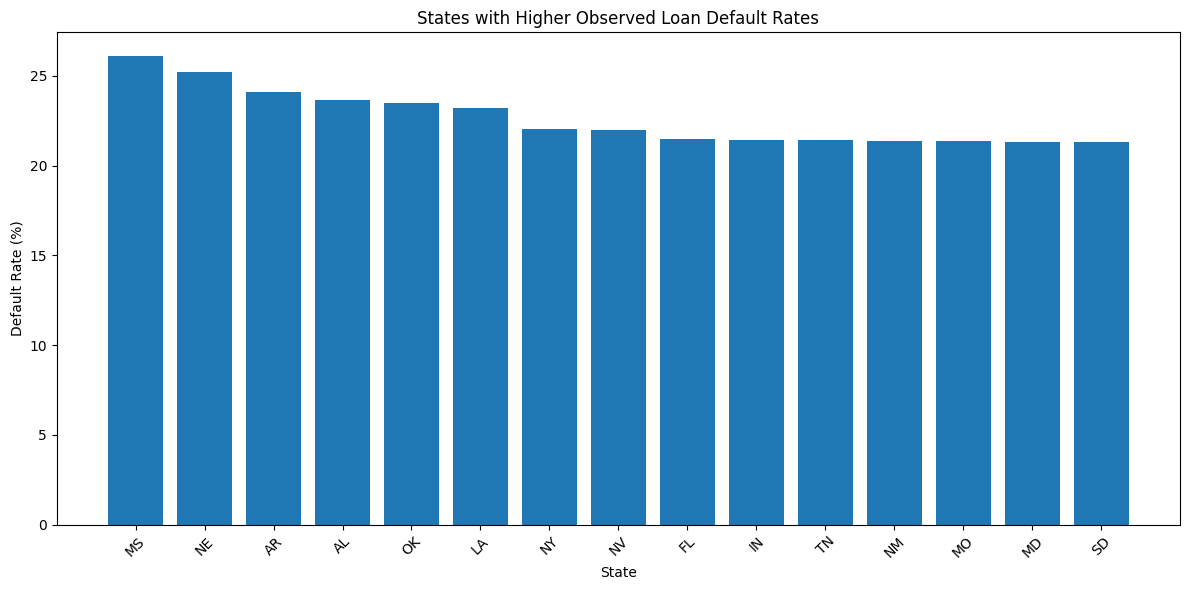

In [ ]:
# ============================================================
# STEP 22: VISUALIZE DEFAULT RATE BY STATE
# ============================================================

# Select the 15 states with the highest observed default rates
# among states with at least 1,000 loans.

top_states = state_default_reliable.head(15)

plt.figure(figsize=(12, 6))

plt.bar(
    top_states.index,
    top_states["default_rate_%"]
)

plt.xlabel("State")
plt.ylabel("Default Rate (%)")
plt.title("States with Higher Observed Loan Default Rates")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 23: DEFINE FINAL MODELING FEATURES
# ============================================================

# These are the variables we will use to predict default risk.
# We are intentionally excluding:
#   - loan_status -> our target
#   - grade/sub_grade -> existing lender risk classification
#
# The goal is to build a risk model from borrower, loan,
# credit and geographic characteristics.

model_features = [
    # Loan characteristics
    "loan_amnt",
    "funded_amnt",
    "term_months",
    "int_rate",
    "installment",
    "purpose",

    # Borrower characteristics
    "annual_inc",
    "emp_length_years",
    "home_ownership",
    "verification_status",

    # Credit characteristics
    "dti_clean",
    "delinq_2yrs",
    "fico_score",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "tot_cur_bal",
    "total_rev_hi_lim",
    "acc_open_past_24mths",
    "avg_cur_bal",
    "bc_util",
    "mort_acc",

    # Geography
    "addr_state"
]

target = "default"

print("Number of model features:", len(model_features))

Number of model features: 26


In [ ]:
# ============================================================
# STEP 24: CREATE FEATURES (X) AND TARGET (y)
# ============================================================

# X = information used to predict default
X = model_data[model_features].copy()

# y = actual historical outcome
y = model_data[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1348099, 26)
y shape: (1348099,)


In [ ]:
# ============================================================
# STEP 25: CHECK MISSING VALUES IN MODEL FEATURES
# ============================================================

missing_model = pd.DataFrame({
    "Missing_Count": X.isnull().sum(),
    "Missing_%": X.isnull().mean() * 100
}).sort_values(
    "Missing_%",
    ascending=False
)

missing_model

,Missing_Count,Missing_%
bc_util,85924,6.373716
emp_length_years,78550,5.826723
avg_cur_bal,70298,5.214602
total_rev_hi_lim,70276,5.212970
tot_cur_bal,70276,5.212970
acc_open_past_24mths,50030,3.711152
mort_acc,50030,3.711152
revol_util,5611,0.416216
dti_clean,909,0.067428
inq_last_6mths,30,0.002225


In [ ]:
# ============================================================
# STEP 26: TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 1078479
Testing rows: 269620


In [ ]:
# ============================================================
# STEP 27.1: IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Identify categorical columns
categorical_features = [
    "purpose",
    "home_ownership",
    "verification_status",
    "addr_state"
]

# Everything else in our model feature list is numerical
numerical_features = [
    col for col in model_features
    if col not in categorical_features
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

print("\nCategorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Numerical features: 22
Categorical features: 4

Categorical:
['purpose', 'home_ownership', 'verification_status', 'addr_state']

Numerical:
['loan_amnt', 'funded_amnt', 'term_months', 'int_rate', 'installment', 'annual_inc', 'emp_length_years', 'dti_clean', 'delinq_2yrs', 'fico_score', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'mort_acc']


In [ ]:
# ============================================================
# STEP 27.2: BUILD THE PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing:
# - Fill missing values with the median
# - Standardize the variables

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Categorical preprocessing:
# - Fill missing values with the most frequent category
# - Convert categories into one-hot encoded columns

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            )
        )
    ]
)

# Combine both preprocessing pipelines

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# ============================================================
# STEP 27.3: CREATE THE LOGISTIC REGRESSION MODEL
# ============================================================

# Logistic Regression is a strong baseline for risk scoring
# because it produces probabilities and is relatively
# interpretable.

logistic_model = LogisticRegression(
    max_iter=100,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

# Combine preprocessing + model into one pipeline

risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

print("Risk model created successfully.")

Risk model created successfully.


In [ ]:
# ============================================================
# STEP 27.4: TRAIN THE BASELINE RISK MODEL
# ============================================================

print("Training Logistic Regression model...")

risk_model.fit(X_train, y_train)

print("Model training completed.")

Training Logistic Regression model...
Model training completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# ============================================================
# STEP 27.5: PREDICT DEFAULT PROBABILITIES
# ============================================================

# Predict the probability that each test-set loan defaults.

y_probability = risk_model.predict_proba(X_test)[:, 1]

print("Number of predictions:", len(y_probability))
print("\nFirst 10 default probabilities:")
print(y_probability[:10])

Number of predictions: 269620

First 10 default probabilities:
[0.30356105 0.10809698 0.33256459 0.11244452 0.14214273 0.11099643
 0.50071254 0.21692061 0.06927356 0.16507746]


In [ ]:
# ============================================================
# STEP 27.6: EVALUATE MODEL PERFORMANCE
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Convert probabilities into predictions using 0.50 threshold

y_pred = (y_probability >= 0.50).astype(int)

# Calculate evaluation metrics

roc_auc = roc_auc_score(y_test, y_probability)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("MODEL PERFORMANCE")
print("=" * 50)
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

MODEL PERFORMANCE
ROC-AUC   : 0.7137
Accuracy  : 0.8026
Precision : 0.5366
Recall    : 0.0891
F1 Score  : 0.1528


In [ ]:
# ============================================================
# STEP 27.7: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Default", "Default"]
    )
)

Confusion Matrix:
[[211605   4143]
 [ 49074   4798]]

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.81      0.98      0.89    215748
     Default       0.54      0.09      0.15     53872

    accuracy                           0.80    269620
   macro avg       0.67      0.53      0.52    269620
weighted avg       0.76      0.80      0.74    269620



In [ ]:
# ============================================================
# STEP 27.8: IMPROVE LOGISTIC REGRESSION CONVERGENCE
# ============================================================

# The previous model reached the maximum number of iterations
# before fully converging.
#
# We increase max_iter so the optimization has more time to
# find stable coefficients.

logistic_model = LogisticRegression(
    max_iter=300,
    solver="saga",
    n_jobs=-1,
    random_state=42
)

# Rebuild the complete pipeline

risk_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", logistic_model)
    ]
)

print("Updated Logistic Regression model created.")

Updated Logistic Regression model created.


In [ ]:
# ============================================================
# STEP 27.9: RETRAIN THE BASELINE MODEL
# ============================================================

print("Retraining Logistic Regression model...")

risk_model.fit(X_train, y_train)

print("Retraining completed.")

Retraining Logistic Regression model...
Retraining completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# ============================================================
# STEP 27.10: GENERATE UPDATED DEFAULT PROBABILITIES
# ============================================================

y_probability = risk_model.predict_proba(X_test)[:, 1]

print("Predictions generated:", len(y_probability))
print("Minimum probability:", y_probability.min())
print("Maximum probability:", y_probability.max())
print("Average probability:", y_probability.mean())

Predictions generated: 269620
Minimum probability: 4.327820541551701e-15
Maximum probability: 0.9001300711622231
Average probability: 0.1996596684846213


In [ ]:
# ============================================================
# STEP 27.11: EVALUATE PROBABILITY RANKING
# ============================================================

roc_auc = roc_auc_score(y_test, y_probability)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.7139


In [ ]:
# ============================================================
# STEP 27.12: EXPLORE RISK THRESHOLDS
# ============================================================

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    # Classify a loan as "review/default" if its
    # predicted probability is at or above the threshold.
    y_threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred
        ),
        "F1": f1_score(
            y_test,
            y_threshold_pred
        ),
        "Applications_Flagged_%": (
            y_threshold_pred.mean() * 100
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1,Applications_Flagged_%
0,0.20,0.324155,0.647498,0.432026,39.911357
1,0.25,0.367229,0.494858,0.421596,26.924931
2,0.30,0.407494,0.370211,0.387959,18.152585
3,0.35,0.444222,0.271421,0.336959,12.208293
4,0.40,0.474737,0.194814,0.276261,8.199318
5,0.45,0.505246,0.134968,0.213029,5.337512
6,0.50,0.536808,0.089471,0.153379,3.330243


In [ ]:
# ============================================================
# STEP 27.12: EXPLORE RISK THRESHOLDS
# ============================================================

# We want to understand how the number of applications
# flagged for review changes when we change the threshold.

thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    # Flag an application when predicted default probability
    # is greater than or equal to the selected threshold.
    y_threshold_pred = (
        y_probability >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred
        ),
        "F1": f1_score(
            y_test,
            y_threshold_pred
        ),
        "Applications_Flagged_%": (
            y_threshold_pred.mean() * 100
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1,Applications_Flagged_%
0,0.20,0.324155,0.647498,0.432026,39.911357
1,0.25,0.367229,0.494858,0.421596,26.924931
2,0.30,0.407494,0.370211,0.387959,18.152585
3,0.35,0.444222,0.271421,0.336959,12.208293
4,0.40,0.474737,0.194814,0.276261,8.199318
5,0.45,0.505246,0.134968,0.213029,5.337512
6,0.50,0.536808,0.089471,0.153379,3.330243


In [ ]:
# ============================================================
# STEP 28.1: CHECK LIGHTGBM AVAILABILITY
# ============================================================

# LightGBM is a gradient-boosting model designed for
# large tabular datasets.

try:
    import lightgbm as lgb
    print("LightGBM version:", lgb.__version__)
    print("LightGBM is available.")

except ImportError:
    print("LightGBM is not installed.")

LightGBM version: 4.6.0
LightGBM is available.


In [ ]:
# ============================================================
# STEP 28.2: PREPARE DATA FOR LIGHTGBM
# ============================================================

# Create copies so we don't accidentally modify our
# original X_train and X_test.

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

# These are the categorical variables in our model.

categorical_features = [
    "purpose",
    "home_ownership",
    "verification_status",
    "addr_state"
]

# Convert categorical columns to pandas category dtype.
# LightGBM can then treat them as categorical features.

for col in categorical_features:
    X_train_lgb[col] = X_train_lgb[col].astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype("category")

print("LightGBM training data:", X_train_lgb.shape)
print("LightGBM testing data:", X_test_lgb.shape)

LightGBM training data: (1078479, 26)
LightGBM testing data: (269620, 26)


In [ ]:
# ============================================================
# STEP 28.3: CREATE LIGHTGBM RISK MODEL
# ============================================================

lgb_model = lgb.LGBMClassifier(
    objective="binary",

    # Number of boosting trees
    n_estimators=300,

    # Smaller learning rate helps produce a more stable model
    learning_rate=0.05,

    # Controls tree complexity
    num_leaves=31,

    # Minimum observations required in a leaf
    min_child_samples=100,

    # Helps reduce overfitting
    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,
    n_jobs=-1
)

print("LightGBM model created.")

LightGBM model created.


In [ ]:
# ============================================================
# STEP 28.4: TRAIN LIGHTGBM RISK MODEL
# ============================================================

print("Training LightGBM model...")

lgb_model.fit(
    X_train_lgb,
    y_train,
    categorical_feature=categorical_features
)

print("LightGBM training completed.")

Training LightGBM model...
[LightGBM] [Info] Number of positive: 215488, number of negative: 862991
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.593834 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3477
[LightGBM] [Info] Number of data points in the train set: 1078479, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199807 -> initscore=-1.387499
[LightGBM] [Info] Start training from score -1.387499
LightGBM training completed.


In [ ]:
# ============================================================
# STEP 28.5: GENERATE LIGHTGBM DEFAULT PROBABILITIES
# ============================================================

# Predict the probability of default for every test-set loan.

lgb_probability = lgb_model.predict_proba(
    X_test_lgb
)[:, 1]

print("Number of predictions:", len(lgb_probability))
print("Minimum probability:", lgb_probability.min())
print("Maximum probability:", lgb_probability.max())
print("Average probability:", lgb_probability.mean())

Number of predictions: 269620
Minimum probability: 0.008903087022604138
Maximum probability: 0.7788332709501014
Average probability: 0.19968399347032595


In [ ]:
# ============================================================
# STEP 28.6: EVALUATE LIGHTGBM
# ============================================================

# Calculate ROC-AUC using predicted probabilities.

lgb_roc_auc = roc_auc_score(
    y_test,
    lgb_probability
)

print(f"LightGBM ROC-AUC: {lgb_roc_auc:.4f}")

LightGBM ROC-AUC: 0.7283


In [ ]:
# ============================================================
# STEP 29: LIGHTGBM THRESHOLD ANALYSIS
# ============================================================

# We will test different probability thresholds to understand
# the trade-off between:
#
#   - How many applications get flagged for review
#   - How many actual defaults we identify
#   - How precise our review list is

lgb_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

lgb_threshold_results = []

for threshold in lgb_thresholds:

    # Flag applications whose predicted default probability
    # is greater than or equal to the threshold.
    lgb_pred = (
        lgb_probability >= threshold
    ).astype(int)

    lgb_threshold_results.append({
        "Threshold": threshold,

        "Precision": precision_score(
            y_test,
            lgb_pred
        ),

        "Recall": recall_score(
            y_test,
            lgb_pred
        ),

        "F1": f1_score(
            y_test,
            lgb_pred
        ),

        "Applications_Flagged_%": (
            lgb_pred.mean() * 100
        )
    })

lgb_threshold_results = pd.DataFrame(
    lgb_threshold_results
)

lgb_threshold_results

,Threshold,Precision,Recall,F1,Applications_Flagged_%
0,0.20,0.327383,0.680539,0.442092,41.534382
1,0.25,0.369033,0.545590,0.440270,29.540093
2,0.30,0.408844,0.420812,0.414742,20.565611
3,0.35,0.449502,0.312370,0.368595,13.885098
4,0.40,0.490887,0.221971,0.305706,9.034938
5,0.45,0.532445,0.149113,0.232979,5.595653
6,0.50,0.579227,0.090993,0.157279,3.138862


In [ ]:
# ============================================================
# STEP 30: LIGHTGBM FEATURE IMPORTANCE
# ============================================================

# Get the importance score for every feature.
#
# Higher values indicate that the feature was used more
# heavily by the trained LightGBM model.

feature_importance = pd.DataFrame({
    "Feature": model_features,
    "Importance": lgb_model.feature_importances_
})

# Sort from most important to least important.

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
25,addr_state,2128
3,int_rate,833
21,acc_open_past_24mths,449
6,annual_inc,426
10,dti_clean,403
0,loan_amnt,367
20,total_rev_hi_lim,347
5,purpose,334
18,total_acc,320
7,emp_length_years,317


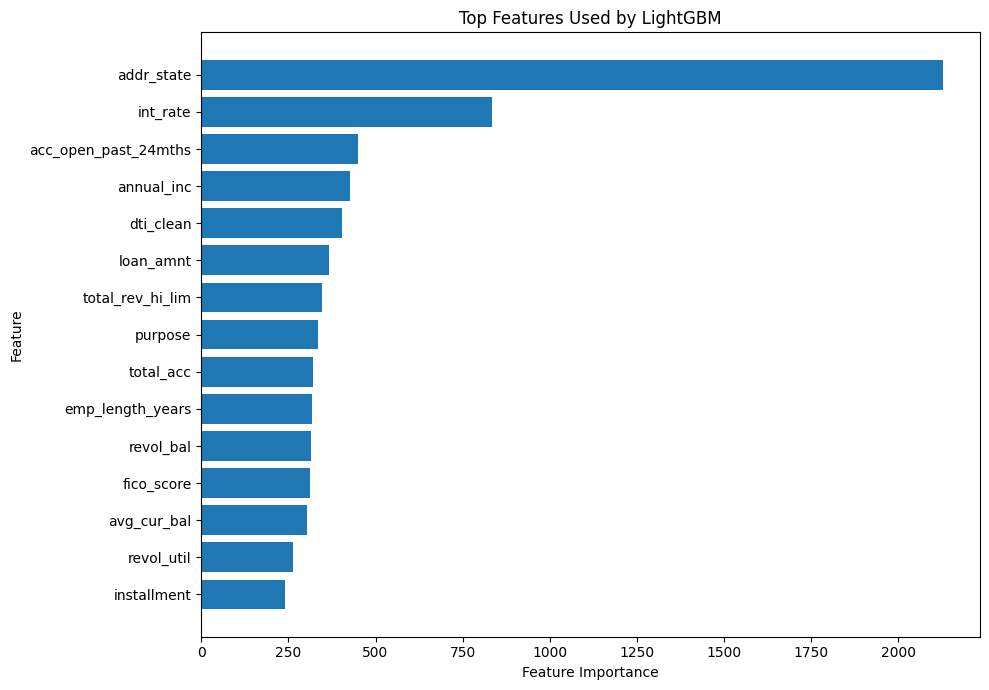

In [ ]:
# ============================================================
# STEP 30.1: VISUALIZE TOP FEATURES
# ============================================================

top_features = feature_importance.head(15).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features Used by LightGBM")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 31: LOAD LOAN ID FOR FINAL SCORING
# ============================================================

id_data = pd.read_csv(
    accepted_path,
    compression="gzip",
    usecols=["id"]
)

# Align the ID with the original dataset index
model_data["loan_id"] = id_data.loc[
    model_data.index, "id"
].values

# Remove temporary dataframe
del id_data

print("Loan ID added successfully.")
print(model_data["loan_id"].head())

/tmp/ipykernel_3008/1679772422.py:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  id_data = pd.read_csv(


Loan ID added successfully.
0    68407277
1    68355089
2    68341763
4    68476807
5    68426831
Name: loan_id, dtype: object


In [ ]:
# ============================================================
# STEP 32: CREATE FINAL SCORING DATASET
# ============================================================

scored_test = model_data.loc[X_test.index].copy()

# Add predicted default probability
scored_test["predicted_default_probability"] = lgb_probability

# Add predicted class using 30% as an exploratory threshold
scored_test["predicted_default"] = (
    scored_test["predicted_default_probability"] >= 0.30
).astype(int)

print("Scored dataset shape:", scored_test.shape)

scored_test[
    [
        "loan_id",
        "loan_amnt",
        "fico_score",
        "dti_clean",
        "predicted_default_probability",
        "predicted_default"
    ]
].head()

Scored dataset shape: (269620, 45)


,loan_id,loan_amnt,fico_score,dti_clean,predicted_default_probability,predicted_default
179613,56699038,32000.0,662.0,20.75,0.301611,1
190815,56592879,6000.0,737.0,15.35,0.110081,0
1929503,1229788,29100.0,742.0,22.70,0.239846,0
121989,60810332,14000.0,682.0,14.89,0.069616,0
304242,46715379,5050.0,677.0,6.16,0.120343,0


In [ ]:
# ============================================================
# STEP 33: CREATE RISK BANDS
# ============================================================

def assign_risk_band(probability):

    if probability < 0.20:
        return "Low Risk"

    elif probability < 0.30:
        return "Moderate Risk"

    elif probability < 0.40:
        return "High Risk"

    else:
        return "Very High Risk"


scored_test["risk_band"] = (
    scored_test["predicted_default_probability"]
    .apply(assign_risk_band)
)

print(scored_test["risk_band"].value_counts())

risk_band
Low Risk          157635
Moderate Risk      56536
High Risk          31089
Very High Risk     24360
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 34: CREATE MANUAL REVIEW FLAG
# ============================================================

review_threshold = 0.30

scored_test["manual_review"] = (
    scored_test["predicted_default_probability"] >= review_threshold
).astype(int)

# Count applications
review_counts = scored_test["manual_review"].value_counts()

print("Manual Review Counts:")
print(review_counts)

# Calculate percentage
review_rate = scored_test["manual_review"].mean() * 100

print(f"\nManual Review Rate: {review_rate:.2f}%")

Manual Review Counts:
manual_review
0    214171
1     55449
Name: count, dtype: int64

Manual Review Rate: 20.57%


In [ ]:
# ============================================================
# STEP 35: VALIDATE RISK BANDS AGAINST OBSERVED OUTCOMES
# ============================================================

risk_band_performance = (
    scored_test
    .groupby("risk_band")["default"]
    .agg(
        Applications="count",
        Observed_Defaults="sum",
        Observed_Default_Rate="mean"
    )
    .reset_index()
)

# Convert default rate to percentage
risk_band_performance["Observed_Default_Rate"] *= 100

# Put bands in logical order
risk_order = [
    "Low Risk",
    "Moderate Risk",
    "High Risk",
    "Very High Risk"
]

risk_band_performance["risk_order"] = (
    risk_band_performance["risk_band"]
    .map({band: i for i, band in enumerate(risk_order)})
)

risk_band_performance = (
    risk_band_performance
    .sort_values("risk_order")
    .drop(columns="risk_order")
)

risk_band_performance

,risk_band,Applications,Observed_Defaults,Observed_Default_Rate
1,Low Risk,157635,17210,10.917626
2,Moderate Risk,56536,13992,24.748833
0,High Risk,31089,10712,34.455917
3,Very High Risk,24360,11958,49.088670


In [ ]:
# ============================================================
# STEP 36: CREATE SQL / POWER BI ANALYSIS FIELDS
# ============================================================

# Income bands
scored_test["income_band"] = pd.cut(
    scored_test["annual_inc"],
    bins=[0, 30000, 50000, 75000, 100000, 150000, float("inf")],
    labels=[
        "<30K",
        "30K-50K",
        "50K-75K",
        "75K-100K",
        "100K-150K",
        "150K+"
    ],
    include_lowest=True
)

# FICO bands
scored_test["fico_band"] = pd.cut(
    scored_test["fico_score"],
    bins=[0, 649, 679, 699, 719, 749, float("inf")],
    labels=[
        "600-649",
        "650-679",
        "680-699",
        "700-719",
        "720-749",
        "750+"
    ]
)

# DTI bands
scored_test["dti_band"] = pd.cut(
    scored_test["dti_clean"],
    bins=[0, 10, 20, 30, 40, 50, float("inf")],
    labels=[
        "<10",
        "10-20",
        "20-30",
        "30-40",
        "40-50",
        "50+"
    ],
    include_lowest=True
)

# Loan amount bands
scored_test["loan_amount_band"] = pd.cut(
    scored_test["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 30000, float("inf")],
    labels=[
        "<5K",
        "5K-10K",
        "10K-15K",
        "15K-20K",
        "20K-30K",
        "30K+"
    ],
    include_lowest=True
)

print("Analysis fields created successfully.")

scored_test[
    [
        "loan_id",
        "income_band",
        "fico_band",
        "dti_band",
        "loan_amount_band",
        "risk_band",
        "manual_review"
    ]
].head()

Analysis fields created successfully.


,loan_id,income_band,fico_band,dti_band,loan_amount_band,risk_band,manual_review
179613,56699038,100K-150K,650-679,20-30,30K+,High Risk,1
190815,56592879,50K-75K,720-749,10-20,5K-10K,Low Risk,0
1929503,1229788,50K-75K,720-749,20-30,20K-30K,Moderate Risk,0
121989,60810332,50K-75K,680-699,10-20,10K-15K,Low Risk,0
304242,46715379,150K+,650-679,<10,5K-10K,Low Risk,0


In [ ]:
# ============================================================
# STEP 37: FINAL DATASET CHECK
# ============================================================

print("Final dataset shape:", scored_test.shape)

print("\nMissing values:")
print(
    scored_test.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

print("\nColumns:")
print(scored_test.columns.tolist())

Final dataset shape: (269620, 48)

Missing values:
bc_util                 17054
emp_length              15577
emp_length_years        15577
avg_cur_bal             13893
total_rev_hi_lim        13889
tot_cur_bal             13889
acc_open_past_24mths     9899
mort_acc                 9899
revol_util               1116
dti_clean                 186
dti_band                  186
dti                        78
income_bracket             74
open_acc                    5
delinq_2yrs                 5
dtype: int64

Columns:
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'application_type', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_util', 'mort_acc', 'default', 'income_bracket'

In [ ]:
# ============================================================
# STEP 38: CREATE FINAL DASHBOARD DATASET
# ============================================================

dashboard_columns = [
    # Application / loan information
    "loan_id",
    "loan_amnt",
    "funded_amnt",
    "term_months",
    "int_rate",
    "installment",

    # Borrower information
    "annual_inc",
    "income_band",
    "emp_length_years",
    "home_ownership",
    "verification_status",

    # Credit information
    "fico_score",
    "fico_band",
    "dti_clean",
    "dti_band",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",

    # Loan purpose / geography
    "purpose",
    "addr_state",

    # Descriptive risk information
    "grade",

    # Model output
    "predicted_default_probability",
    "predicted_default",
    "risk_band",
    "manual_review"
]

dashboard_data = scored_test[dashboard_columns].copy()

print("Dashboard dataset shape:", dashboard_data.shape)

dashboard_data.head()

Dashboard dataset shape: (269620, 29)


,loan_id,loan_amnt,funded_amnt,term_months,int_rate,installment,annual_inc,income_band,emp_length_years,home_ownership,...,revol_bal,revol_util,total_acc,purpose,addr_state,grade,predicted_default_probability,predicted_default,risk_band,manual_review
179613,56699038,32000.0,32000.0,36.0,13.99,1093.53,130000.0,100K-150K,6.0,OWN,...,16891.0,70.7,37.0,credit_card,MI,C,0.301611,1,High Risk,1
190815,56592879,6000.0,6000.0,36.0,10.99,196.41,51596.0,50K-75K,10.0,MORTGAGE,...,5609.0,27.4,16.0,credit_card,TX,B,0.110081,0,Low Risk,0
1929503,1229788,29100.0,29100.0,60.0,13.11,663.76,60000.0,50K-75K,10.0,RENT,...,37325.0,62.4,21.0,debt_consolidation,NY,B,0.239846,0,Moderate Risk,0
121989,60810332,14000.0,14000.0,36.0,7.26,433.95,65850.0,50K-75K,5.0,RENT,...,4223.0,13.3,28.0,credit_card,CA,A,0.069616,0,Low Risk,0
304242,46715379,5050.0,5050.0,36.0,10.99,165.31,162000.0,150K+,10.0,MORTGAGE,...,2593.0,21.8,43.0,major_purchase,IN,B,0.120343,0,Low Risk,0


In [ ]:
# ============================================================
# STEP 39: HANDLE CATEGORICAL MISSING VALUES
# ============================================================

categorical_dashboard_columns = [
    "income_band",
    "fico_band",
    "dti_band",
    "purpose",
    "home_ownership",
    "verification_status",
    "addr_state",
    "grade"
]

for col in categorical_dashboard_columns:
    dashboard_data[col] = (
        dashboard_data[col]
        .astype("object")
        .fillna("Unknown")
    )

print("Categorical missing values handled.")

Categorical missing values handled.


In [ ]:
# ============================================================
# STEP 40: CALCULATE LOAN EXPOSURE
# ============================================================

dashboard_data["manual_review_exposure"] = (
    dashboard_data["loan_amnt"]
    .where(dashboard_data["manual_review"] == 1, 0)
)

dashboard_data["high_risk_exposure"] = (
    dashboard_data["loan_amnt"]
    .where(
        dashboard_data["risk_band"].isin(
            ["High Risk", "Very High Risk"]
        ),
        0
    )
)

print("Exposure fields created.")

dashboard_data[
    [
        "loan_id",
        "loan_amnt",
        "predicted_default_probability",
        "risk_band",
        "manual_review",
        "manual_review_exposure",
        "high_risk_exposure"
    ]
].head()

Exposure fields created.


,loan_id,loan_amnt,predicted_default_probability,risk_band,manual_review,manual_review_exposure,high_risk_exposure
179613,56699038,32000.0,0.301611,High Risk,1,32000.0,32000.0
190815,56592879,6000.0,0.110081,Low Risk,0,0.0,0.0
1929503,1229788,29100.0,0.239846,Moderate Risk,0,0.0,0.0
121989,60810332,14000.0,0.069616,Low Risk,0,0.0,0.0
304242,46715379,5050.0,0.120343,Low Risk,0,0.0,0.0


In [ ]:
# ============================================================
# STEP 41: FINAL QUALITY CHECK
# ============================================================

print("Final dashboard dataset shape:")
print(dashboard_data.shape)

print("\nMissing values:")
print(
    dashboard_data.isnull()
    .sum()
    .sort_values(ascending=False)
)

print("\nRisk distribution:")
print(
    dashboard_data["risk_band"]
    .value_counts()
)

print("\nManual review distribution:")
print(
    dashboard_data["manual_review"]
    .value_counts()
)

print("\nPredicted probability summary:")
print(
    dashboard_data["predicted_default_probability"]
    .describe()
)

Final dashboard dataset shape:
(269620, 31)

Missing values:
emp_length_years                 15577
revol_util                        1116
dti_clean                          186
inq_last_6mths                       5
open_acc                             5
delinq_2yrs                          5
pub_rec                              5
total_acc                            5
installment                          0
annual_inc                           0
loan_id                              0
term_months                          0
int_rate                             0
loan_amnt                            0
funded_amnt                          0
dti_band                             0
fico_band                            0
fico_score                           0
verification_status                  0
income_band                          0
home_ownership                       0
revol_bal                            0
purpose                              0
addr_state                           0
gra

In [ ]:
# ============================================================
# STEP 42: EXPORT FINAL DASHBOARD DATASET
# ============================================================

dashboard_path = "loan_risk_dashboard.csv"

dashboard_data.to_csv(
    dashboard_path,
    index=False
)

print(f"Dashboard dataset exported to: {dashboard_path}")
print(f"Rows: {len(dashboard_data):,}")
print(f"Columns: {len(dashboard_data.columns)}")

Dashboard dataset exported to: loan_risk_dashboard.csv
Rows: 269,620
Columns: 31


In [ ]:
# ============================================================
# STEP 42A: DOWNLOAD DATASET TO COMPUTER
# ============================================================

from google.colab import files

files.download("loan_risk_dashboard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>